<a href="https://colab.research.google.com/github/thvsbg/PyTorch/blob/main/Plotting_decision_boundary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


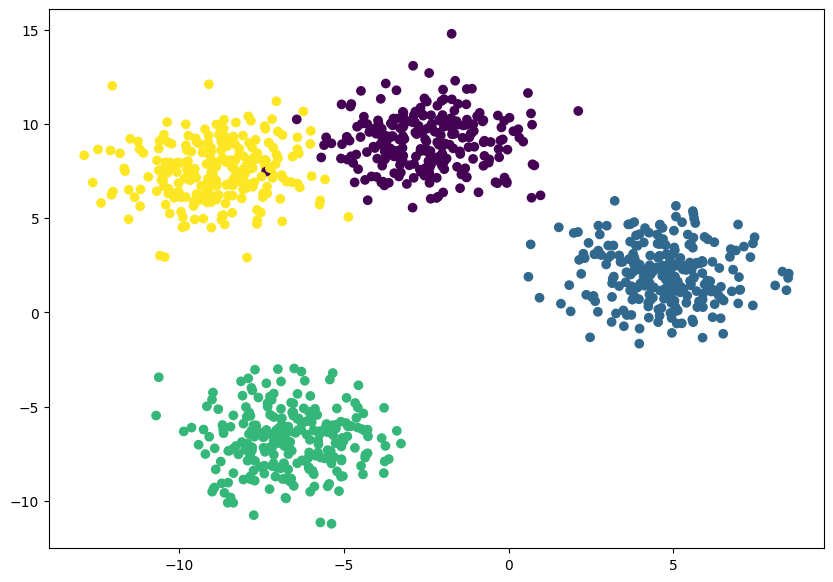

In [ ]:
from sklearn.datasets import make_blobs

NUM_CLASSES=4
NUM_FEATURES=2

X_blob,y_blob=make_blobs(n_samples=1000,n_features=NUM_FEATURES,centers=NUM_CLASSES,random_state=42,cluster_std=1.5)

plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob)


In [ ]:
import torch
from torch import nn
torch.manual_seed(42)

class BlobModelV0(nn.Module):
  def __init__(self,input_features,output_features,hidden_units):
    super().__init__()
    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)

model_0=BlobModelV0(2,4,8)


In [ ]:
s_dict=torch.load("blob_model.pth",weights_only=True)
model_0.load_state_dict(s_dict)

<All keys matched successfully>

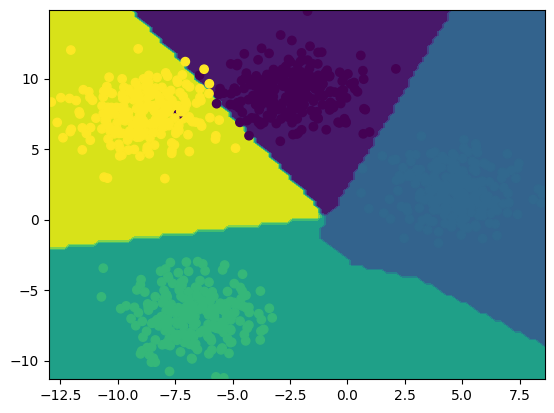

In [110]:
import torch
X_min,X_max=X_blob[:,0].min()-0.1,X_blob[:,0].max()+0.1
y_min,y_max=X_blob[:,1].min()-0.1,X_blob[:,1].max()+0.1

xx,yy=np.linspace(X_min,X_max,101),np.linspace(y_min,y_max,101)
x,y=np.meshgrid(xx,yy)

X_test=np.c_[x.ravel(),y.ravel()]
# print(X_test)
X_test=torch.from_numpy(X_test).type(torch.float)

model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test)
  y_pred_prob=torch.softmax(y_logits,dim=1)
  y_pred=torch.argmax(y_pred_prob,dim=1)
  y_pred=y_pred.detach().numpy()

# Reshape y_pred to match the 2D grid for contourf
y_pred_reshaped=y_pred.reshape(x.shape)

plt.contourf(x,y,y_pred_reshaped)
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob)

# print(y_pred.shape)
# print(y_pred_reshaped.shape)
# print(xx.shape)



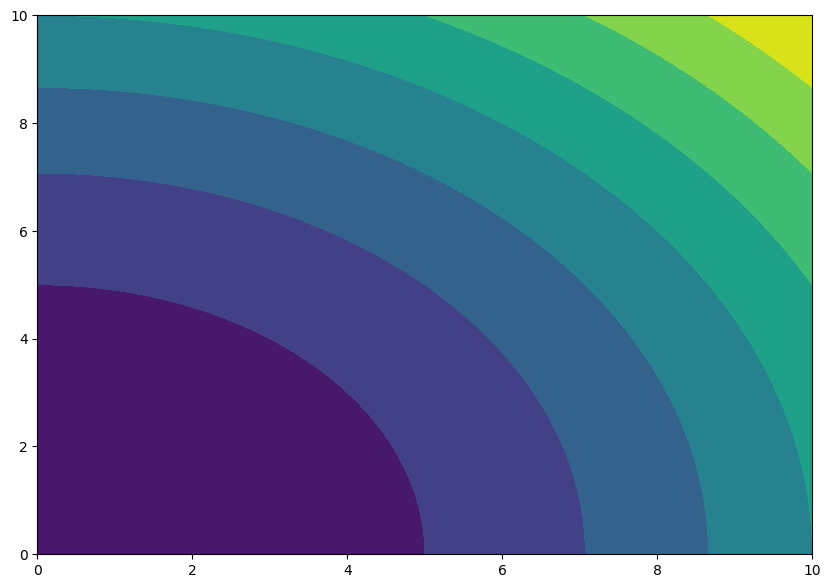

In [ ]:
import math
x=np.linspace(0,10,101)


xx,yy=np.linspace(0,10,101),np.linspace(0,10,101)
x,y=np.meshgrid(xx,yy)
func=(x**2+y**2)
plt.figure(figsize=(10,7))
plt.contourf(x,y,func)